<h2>1. Libraries Import</h2>

In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
from collections import Counter
from wordcloud import WordCloud, STOPWORDS
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
import pickle
import os

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

<h2>2. Loding Dataset</h2>

In [2]:
df = pd.read_csv("IMDB Dataset.csv", engine='python', escapechar='\\', on_bad_lines='skip')

<h2>3. Explainatory Data Analysis</h2>

In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [6]:
df.isnull().sum()

,0
review,0
sentiment,0


In [7]:
duplicate_count = df.duplicated().sum()
print(f'Duplicate Rows: {duplicate_count}')

Duplicate Rows: 418


In [8]:
news_df = df.drop_duplicates()

<h2>4. Data Visualization</h2>

Bar Graph

<Axes: title={'center': 'Sentiment Distribution'}, xlabel='sentiment'>

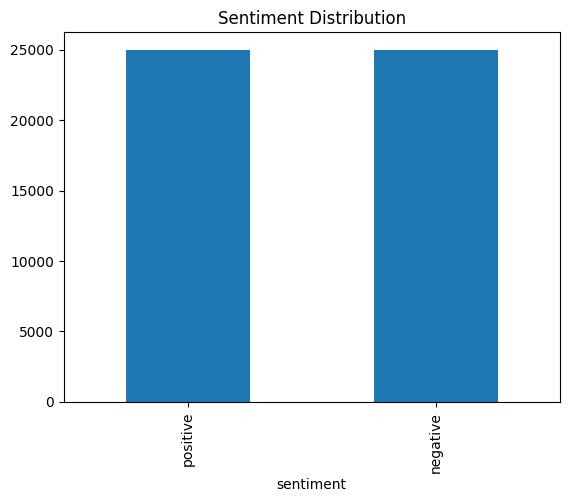

In [9]:
df['sentiment'].value_counts().plot(kind='bar', title='Sentiment Distribution')

Pie Chart

<Axes: title={'center': 'Sentiment Distribution'}>

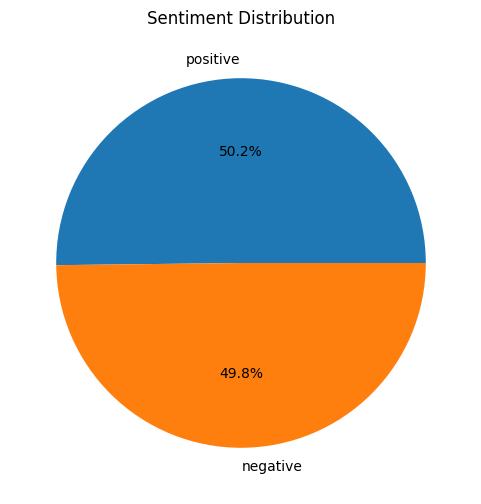

In [10]:
news_df['sentiment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6, 6),
    title='Sentiment Distribution',
    ylabel=''
)

Histogram

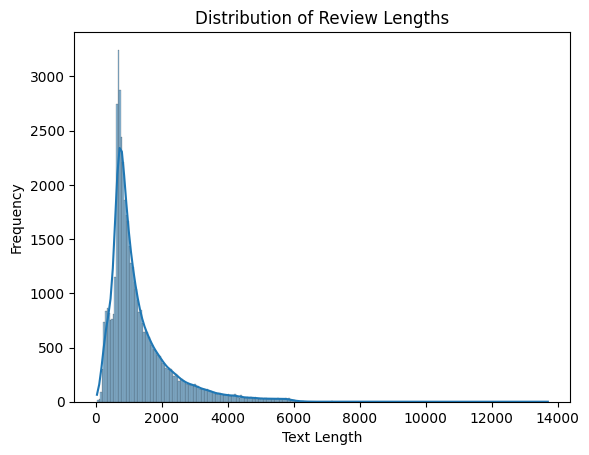

In [11]:
df['review_length'] = df['review'].apply(len)

#plotting a histogram to show the distribution of text length
sns.histplot(df['review_length'], kde=True)
plt.title('Distribution of Review Lengths')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()

Word Cloud

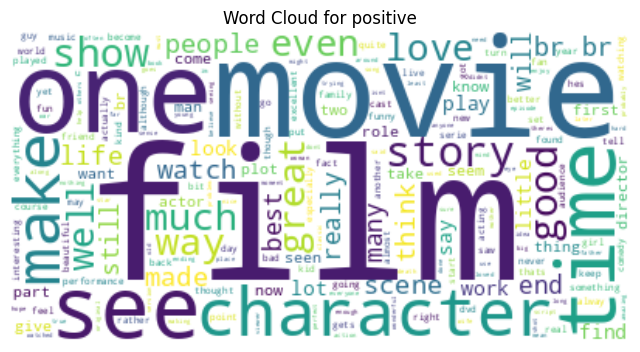

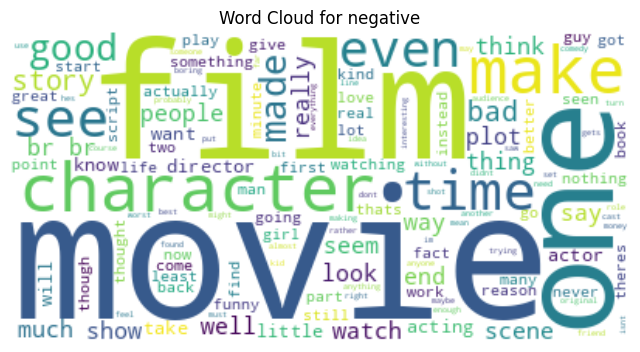

In [12]:
custom_stopwords = set(STOPWORDS)
import string

for label in df['sentiment'].unique():
    subset = df[df['sentiment'] == label]
    review = ' '.join(subset['review']).lower()  # combining the texts and converting to lowercase
    review = review.translate(str.maketrans('', '', string.punctuation))  # Removing punctuation
    wordcloud = WordCloud(stopwords=custom_stopwords, background_color='white').generate(review) #creating a word cloud with the given text, excluding stop words (custom_stopwords) and using a white background.
    plt.figure(figsize=(8, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud for {label}')
    plt.show()

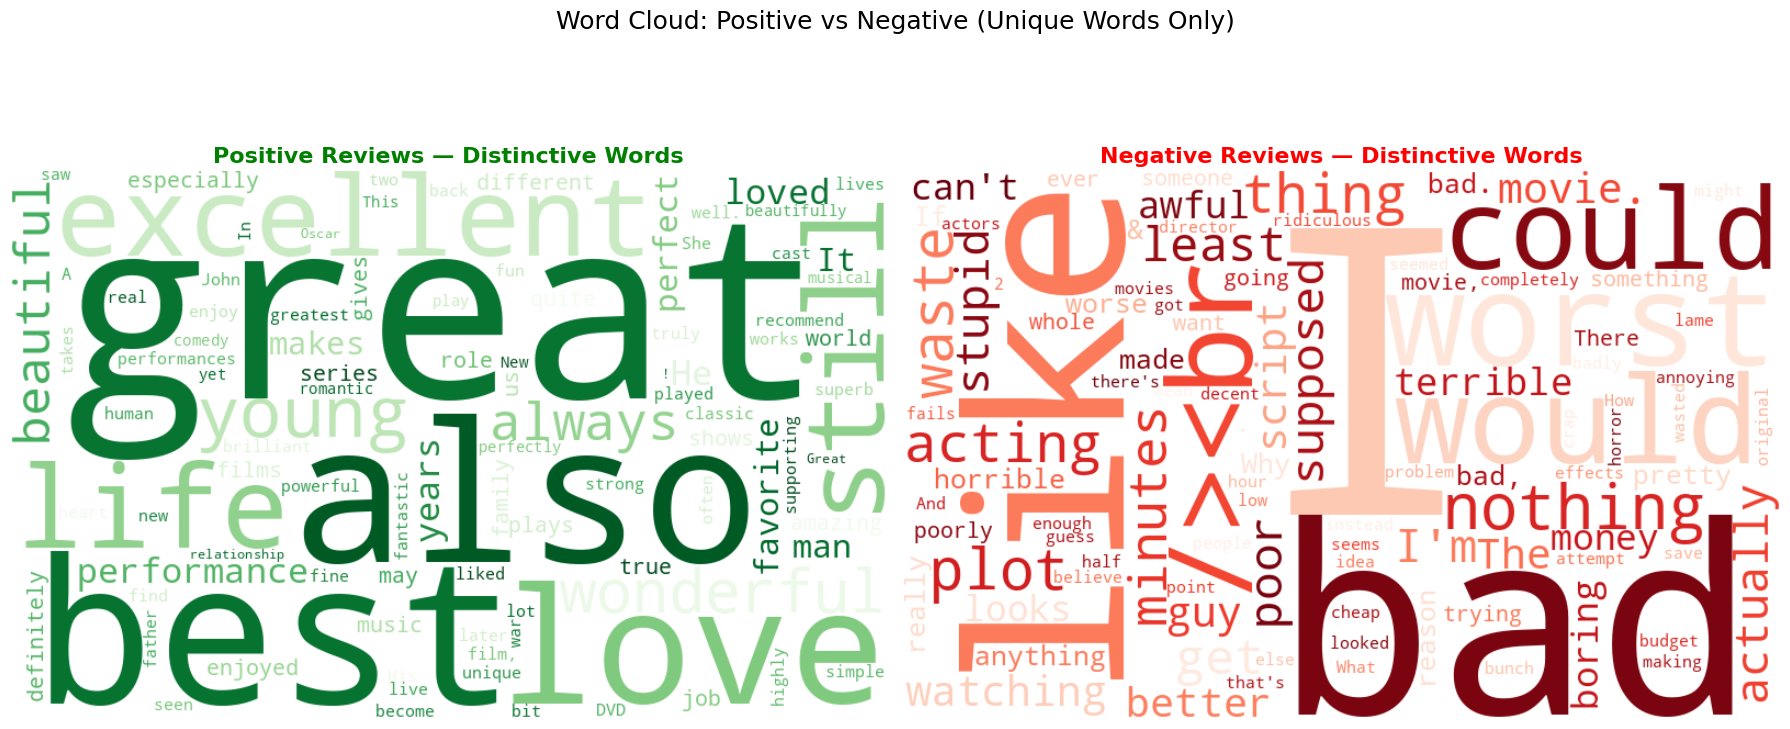

In [13]:
nltk_stops = set(stopwords.words('english'))

domain_stops = {"movie", "film", "one", "see", "time", "even",
                "story", "make", "watch", "well", "much", "come",
                "br", "show", "think", "know", "say", "look",
                "first", "many", "though", "will", "way", "take"}

all_stops = nltk_stops | domain_stops

# Splitting reviews by sentiment
pos_reviews = df[df['sentiment'] == 'positive']['review']
neg_reviews = df[df['sentiment'] == 'negative']['review']

# Building word frequencies (filter stopwords during split)
pos_words = [w for w in ' '.join(pos_reviews).split() if w not in all_stops]
neg_words = [w for w in ' '.join(neg_reviews).split() if w not in all_stops]

pos_freq = Counter(pos_words)
neg_freq = Counter(neg_words)

pos_unique_freq = {
    word: pos_freq[word] - neg_freq.get(word, 0)
    for word in pos_freq
    if pos_freq[word] - neg_freq.get(word, 0) > 0
}

neg_unique_freq = {
    word: neg_freq[word] - pos_freq.get(word, 0)
    for word in neg_freq
    if neg_freq[word] - pos_freq.get(word, 0) > 0
}

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

wc_pos = WordCloud(
    width=800, height=500,
    background_color='white',
    colormap='Greens',
    max_words=100,
    collocations=False,
    stopwords=all_stops
).generate_from_frequencies(pos_unique_freq)

wc_neg = WordCloud(
    width=800, height=500,
    background_color='white',
    colormap='Reds',
    max_words=100,
    collocations=False,
    stopwords=all_stops
).generate_from_frequencies(neg_unique_freq)

axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Positive Reviews — Distinctive Words', fontsize=16, fontweight='bold', color='green')

axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Negative Reviews — Distinctive Words', fontsize=16, fontweight='bold', color='red')

plt.suptitle('Word Cloud: Positive vs Negative (Unique Words Only)', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

<h2>5. Preprocessing</h2>

In [14]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

Lowering

In [15]:
df['review'].str.lower()

,review
0,one of the other reviewers has mentioned that ...
1,a wonderful little production. <br /><br />the...
2,i thought this was a wonderful way to spend ti...
3,basically there's a family where a little boy ...
4,"petter mattei's ""love in the time of money"" is..."
...,...
49995,i thought this movie did a down right good job...
49996,"bad plot, bad dialogue, bad acting, idiotic di..."
49997,i am a catholic taught in parochial elementary...
49998,i'm going to have to disagree with the previou...


In [16]:
df['review'] = df['review'].str.lower()

In [17]:
df.head()

,review,sentiment,review_length
0,one of the other reviewers has mentioned that ...,positive,1761
1,a wonderful little production. <br /><br />the...,positive,998
2,i thought this was a wonderful way to spend ti...,positive,926
3,basically there's a family where a little boy ...,negative,748
4,"petter mattei's ""love in the time of money"" is...",positive,1317


Removing HTML Tags

In [18]:
def remove_html_tag(text):
    pattern = re.compile(r'<.*?>')
    return pattern.sub('',text)

In [19]:
df['review']=df['review'].apply(remove_html_tag)

Removing URLs

In [20]:
def remove_urls(text):
    pattern = re.compile(r'https?://\S+|www\.\S+')
    return pattern.sub(r'',text)

In [21]:
df['review']=df['review'].apply(remove_html_tag)

Removing Punctuation

In [22]:
df['review'] = df['review'].apply(lambda x: re.sub(r'[^\w\s]', '', x))

Removing Digits

In [23]:
df['review'] = df['review'].apply(lambda x: re.sub(r'\d+', '', x))

Tokenization + Remove stop words + Lemmitization

In [24]:
def preprocess_row(text):
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return ' '.join(tokens)

df['review'] = df['review'].apply(preprocess_row)

<h2>6. Feature Extraction + Train/Test Split</h2>

Label Encoding

In [25]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])

Train/Test Split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['label'],
    test_size=0.2,
    random_state=42
)

Feature Extraction Using TF-IDF Vectorization

In [27]:
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2), stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

<h2>7. Model Training</h2>

Training using Naive Bayes Model

In [28]:
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

MultinomialNB()

Training using Logistic Regression Model

In [29]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

Training using SVM Model

In [30]:
svm = LinearSVC()
svm.fit(X_train_tfidf, y_train)

LinearSVC()

<h2>8. Model Evaluation</h2>

Accuracy and Classification Report

In [31]:
models = {'Logistic Regression': lr, 'Naive Bayes': nb, 'SVM': svm}

for name, model in models.items():
    y_pred = model.predict(X_test_tfidf)
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred, target_names=['Negative','Positive']))


  Logistic Regression
Accuracy : 0.8888
              precision    recall  f1-score   support

    Negative       0.90      0.87      0.89      4961
    Positive       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000


  Naive Bayes
Accuracy : 0.8557
              precision    recall  f1-score   support

    Negative       0.86      0.84      0.85      4961
    Positive       0.85      0.87      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000


  SVM
Accuracy : 0.8797
              precision    recall  f1-score   support

    Negative       0.89      0.87      0.88      4961
    Positive       0.87      0.89      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      

Confusion Matrix

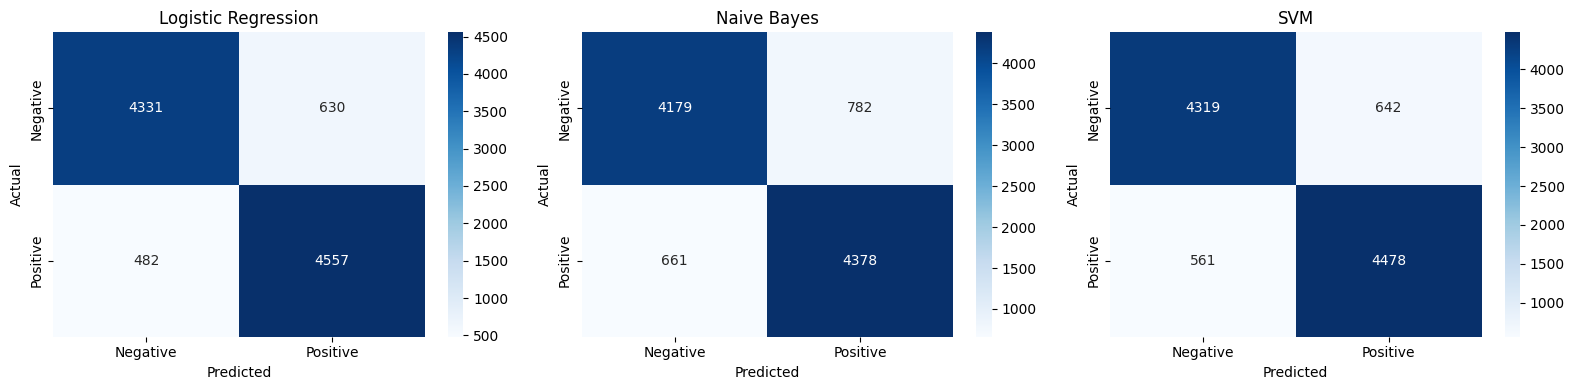

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_tfidf)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Negative','Positive'],
                yticklabels=['Negative','Positive'])
    ax.set_title(name)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

ROC-AUC Curve

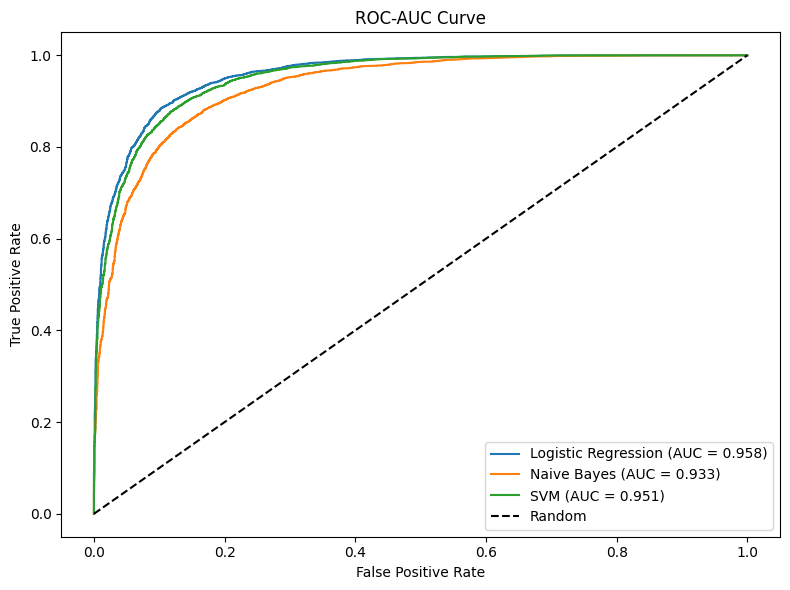

In [33]:
plt.figure(figsize=(8, 6))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_tfidf)[:, 1]
    else:
        y_prob = model.decision_function(X_test_tfidf)  # for SVM

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve')
plt.legend()
plt.tight_layout()
plt.show()

<h2>9. Saving Model</h2>

In [34]:
os.makedirs('models', exist_ok=True)

# Saving Logistic Regression model
with open('models/lr_model.pkl', 'wb') as f:
    pickle.dump(lr, f)

# Saving TF-IDF vectorizer
with open('models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

# Saving Label Encoder
with open('models/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("Models saved successfully!")

Models saved successfully!


<h2>10. Prediction on new Review Data</h2>

In [35]:
with open('models/lr_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

with open('models/tfidf_vectorizer.pkl', 'rb') as f:
    loaded_tfidf = pickle.load(f)

with open('models/label_encoder.pkl', 'rb') as f:
    loaded_le = pickle.load(f)

def predict_sentiment(review):
    clean = preprocess_row(review)
    vec   = loaded_tfidf.transform([clean])
    pred  = loaded_model.predict(vec)[0]
    prob  = loaded_model.predict_proba(vec)[0][pred]
    label = loaded_le.inverse_transform([pred])[0]
    print(f"Review    : {review}")
    print(f"Sentiment : {label.upper()}")
    print(f"Confidence: {prob*100:.1f}%")

predict_sentiment("One of the best movies I have ever seen. Truly masterpiece!")
predict_sentiment("Absolutely terrible. Worst movie of the year, avoid it.")

Review    : One of the best movies I have ever seen. Truly masterpiece!
Sentiment : POSITIVE
Confidence: 97.9%
Review    : Absolutely terrible. Worst movie of the year, avoid it.
Sentiment : NEGATIVE
Confidence: 99.7%
